<a href="https://colab.research.google.com/github/dineshkarthikmcse2025-hue/DAA-EXPT/blob/main/DAA%20EXP%208.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5-City TSP Cost Matrix

         A     B     C     D     E
   A   INF    10     8     9     7
   B    10   INF    10     5     6
   C     8    10   INF     8     9
   D     9     5     8   INF     6
   E     7     6     9     6   INF

Optimal Tour:
A -> C -> D -> B -> E -> A

Minimum Cost: 34

Path Details
A -> C = 8
C -> D = 8
D -> B = 5
B -> E = 6
E -> A = 7


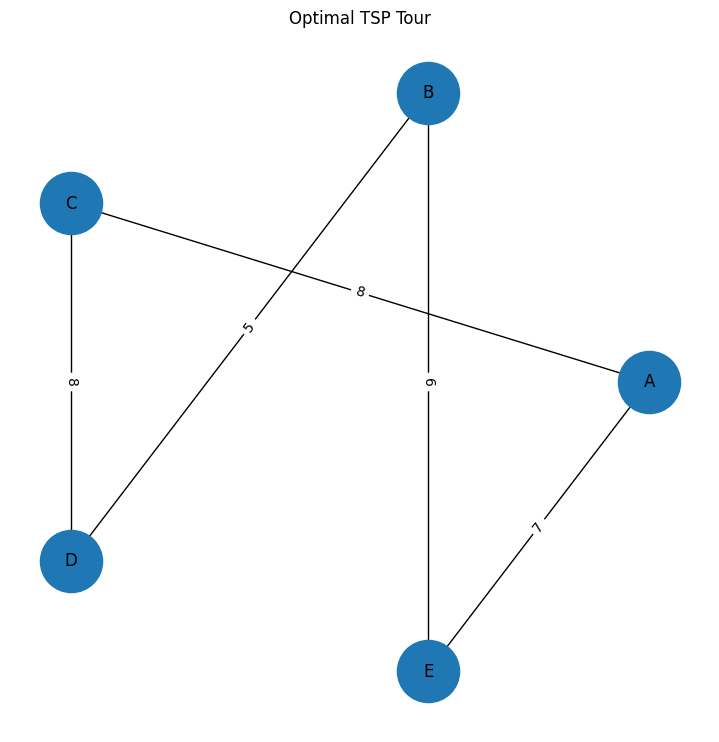

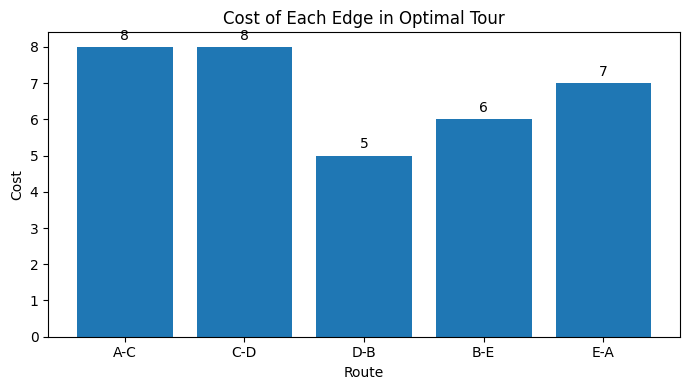

In [1]:

import matplotlib.pyplot as plt
import networkx as nx
from itertools import permutations

INF = float('inf')


def tsp_brute_force(cost, n):
    """Brute Force TSP"""

    cities = list(range(1, n))

    best_cost = INF
    best_path = None

    for perm in permutations(cities):
        path = [0] + list(perm) + [0]

        total = 0
        for i in range(n):
            total += cost[path[i]][path[i + 1]]

        if total < best_cost:
            best_cost = total
            best_path = path

    return best_path, best_cost


# ---------------- Cost Matrix ----------------

cost = [
    [INF, 10, 8, 9, 7],
    [10, INF, 10, 5, 6],
    [8, 10, INF, 8, 9],
    [9, 5, 8, INF, 6],
    [7, 6, 9, 6, INF]
]

cities = ['A', 'B', 'C', 'D', 'E']
n = len(cities)

best_path, best_cost = tsp_brute_force(cost, n)

print("5-City TSP Cost Matrix\n")

print(f'{"":>4}', end="")
for c in cities:
    print(f"{c:>6}", end="")
print()

for i in range(n):
    print(f"{cities[i]:>4}", end="")
    for j in range(n):
        if cost[i][j] == INF:
            print(f"{'INF':>6}", end="")
        else:
            print(f"{cost[i][j]:>6}", end="")
    print()

print("\nOptimal Tour:")
print(" -> ".join(cities[i] for i in best_path))

print("\nMinimum Cost:", best_cost)

print("\nPath Details")

edge_costs = []

for i in range(n):
    u = best_path[i]
    v = best_path[i + 1]
    c = cost[u][v]
    edge_costs.append(c)
    print(f"{cities[u]} -> {cities[v]} = {c}")


# ---------------- Graph 1 : Optimal Tour ----------------

G = nx.Graph()

for city in cities:
    G.add_node(city)

for i in range(n):
    u = cities[best_path[i]]
    v = cities[best_path[i + 1]]
    G.add_edge(u, v, weight=cost[best_path[i]][best_path[i + 1]])

pos = nx.circular_layout(G)

plt.figure(figsize=(7,7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=12
)

labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Optimal TSP Tour")
plt.show()


# ---------------- Graph 2 : Edge Cost ----------------

edges = []

for i in range(n):
    edges.append(f"{cities[best_path[i]]}-{cities[best_path[i+1]]}")

plt.figure(figsize=(7,4))

plt.bar(edges, edge_costs)

plt.title("Cost of Each Edge in Optimal Tour")
plt.xlabel("Route")
plt.ylabel("Cost")

for i, v in enumerate(edge_costs):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()

